# Phân tích khám phá dữ liệu


In [9]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

# Nạp dữ liệu


In [10]:
df_train = pd.read_csv('../../../data/train.csv')
df_test = pd.read_csv('../../../data/test.csv')

In [11]:
df_train.head(10)

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.1060,0.2350,152.429,204947.000000,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.046800,0.1040,0.3800,132.921,191956.000000,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.635000,0.2840,0.6350,159.953,161037.000000,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.021300,0.3000,0.5010,172.472,298093.000000,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.2110,0.6190,88.311,254145.000000,4,5
5,6,Beck,Fuckin With My Head (Mountain Dew Rock),38.0,0.657,0.813,7.0,-7.861,1,0.2160,0.008340,0.049200,0.2080,0.5890,82.035,219587.000000,4,10
6,7,Shadow and Light,Blue,11.0,0.658,0.431,1.0,-12.718,0,0.0300,0.615000,0.292000,0.0902,0.5280,132.045,3.893933,5,0
7,8,Within The Ruins,Devil In Me,45.0,0.441,0.994,7.0,-2.934,1,0.2390,0.000073,0.000147,0.3820,0.0478,139.931,213125.000000,4,8
8,9,Crazy Cavan,My Little Sister Gotta Motorbike,38.0,0.446,0.816,9.0,-9.762,1,0.0766,0.318000,NaN,0.3390,0.7180,183.696,165293.000000,4,10
9,10,Day Sulan,Bailar,58.0,0.852,0.535,7.0,-5.940,0,0.0896,0.439000,0.000082,0.2460,0.4830,103.007,205056.000000,4,5


# Kiểm tra missing value


In [12]:
df_train.isna().sum()

Id                       0
Artist Name              0
Track Name               0
Popularity             333
danceability             0
energy                   0
key                   1609
loudness                 0
mode                     0
speechiness              0
acousticness             0
instrumentalness      3541
liveness                 0
valence                  0
tempo                    0
duration_in min/ms       0
time_signature           0
Class                    0
dtype: int64

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396 non-null  float64
 16  time

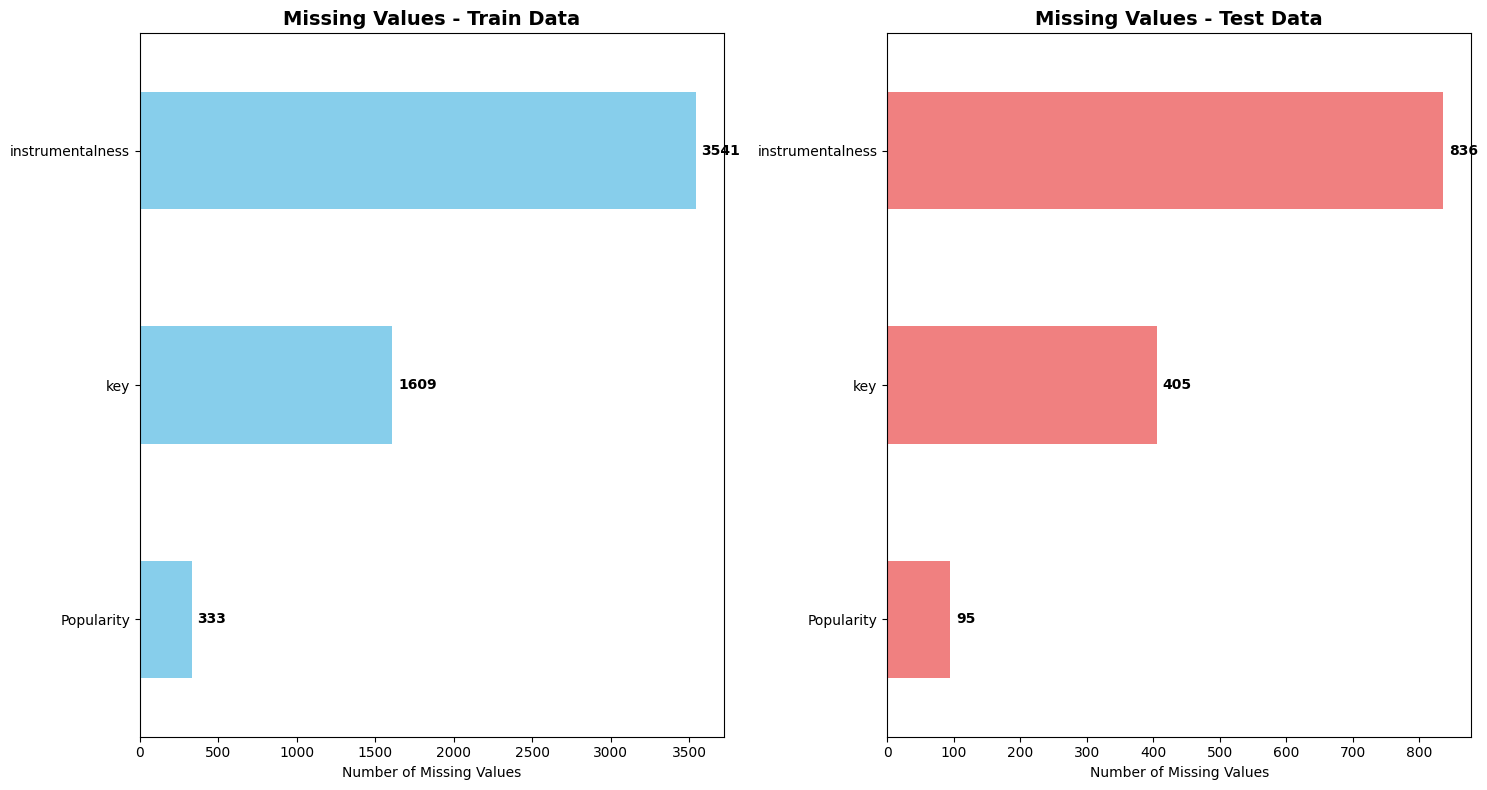

Số lượng cột bị thiếu giá trị trong train data: 3
Số lượng cột bị thiếu giá trị trong test data: 3


In [14]:
# Tính missing values
missing_train = df_train.isnull().sum()
missing_test = df_test.isnull().sum()

# Lọc chỉ các cột có missing values
missing_train = missing_train[missing_train > 0]
missing_test = missing_test[missing_test > 0]

# Sắp xếp theo thứ tự giảm dần để dễ nhìn
missing_train = missing_train.sort_values(ascending=True)
missing_test = missing_test.sort_values(ascending=True)

# Vẽ biểu đồ ngang
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Train data
if len(missing_train) > 0:
    missing_train.plot.barh(ax=ax1, color='skyblue')
    ax1.set_title('Missing Values - Train Data', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Missing Values')
    
    # Thêm giá trị lên cột
    for i, v in enumerate(missing_train):
        ax1.text(v + max(missing_train.values)*0.01, i, str(v), 
                va='center', fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
             transform=ax1.transAxes, fontsize=12)

# Test data
if len(missing_test) > 0:
    missing_test.plot.barh(ax=ax2, color='lightcoral')
    ax2.set_title('Missing Values - Test Data', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Missing Values')
    
    # Thêm giá trị lên cột
    for i, v in enumerate(missing_test):
        ax2.text(v + max(missing_test.values)*0.01, i, str(v), 
                va='center', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
             transform=ax2.transAxes, fontsize=12)

plt.tight_layout()
plt.show()

print("Số lượng cột bị thiếu giá trị trong train data:", len(missing_train))
print("Số lượng cột bị thiếu giá trị trong test data:", len(missing_test))

<Axes: >

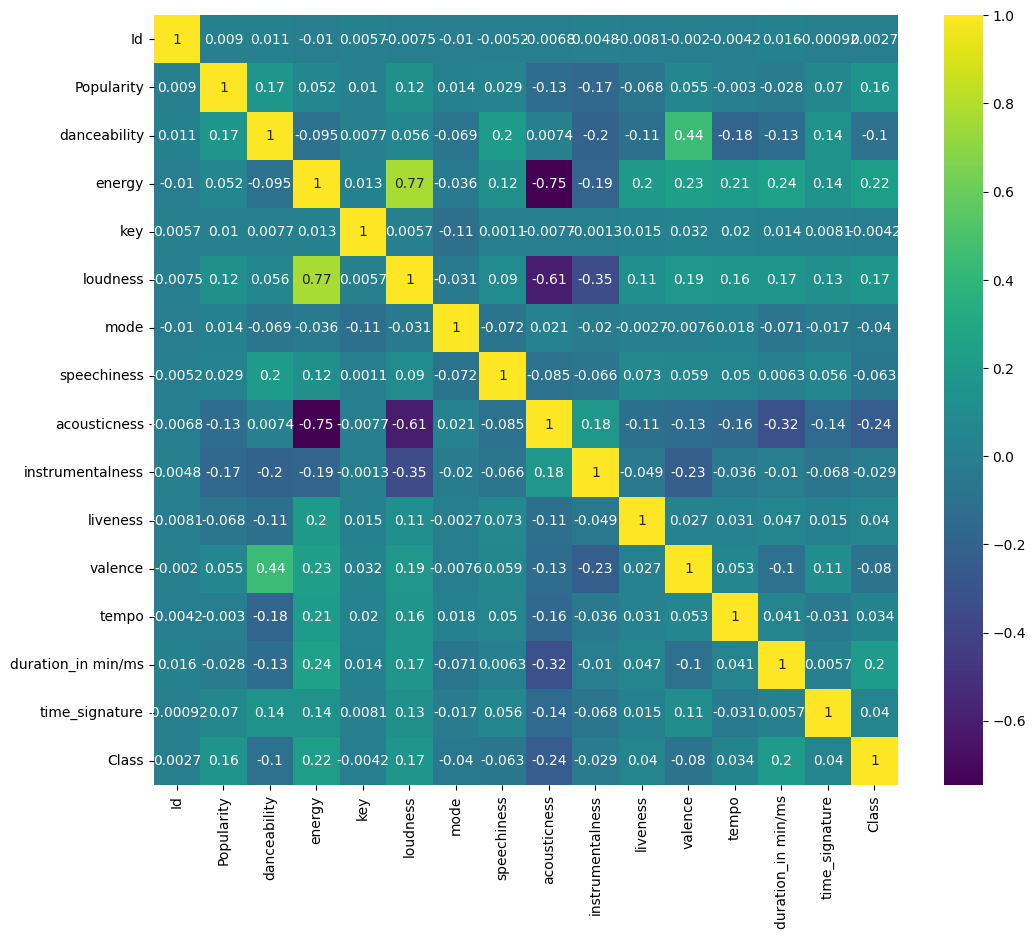

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_train.select_dtypes(include=['number']).corr(), cmap='viridis', annot=True)

In [16]:
# sss

# Sử lý missing value


In [17]:
df_train['Popularity'].value_counts()

Popularity
42.0     371
41.0     357
34.0     348
43.0     343
44.0     333
        ... 
91.0       3
100.0      2
96.0       2
98.0       1
99.0       1
Name: count, Length: 100, dtype: int64

In [18]:
df_train['Popularity'].fillna(df_train['Popularity'].mean(), inplace=True)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7192\3991087574.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Popularity'].fillna(df_train['Popularity'].mean(), inplace=True)


In [19]:
df_train['key'].value_counts()

key
7.0     1650
9.0     1590
2.0     1582
1.0     1351
4.0     1252
11.0    1176
5.0     1115
6.0      963
8.0      872
10.0     825
3.0      411
Name: count, dtype: int64

In [20]:
df_train['key'].fillna(df_train['key'].median(), inplace=True)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_7192\2260858854.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['key'].fillna(df_train['key'].median(), inplace=True)


In [21]:
df_train['instrumentalness'].value_counts()

instrumentalness
0.000109    18
0.929000    17
0.914000    16
0.899000    16
0.927000    15
            ..
0.701000     1
0.000002     1
0.000070     1
0.088400     1
0.000007     1
Name: count, Length: 3945, dtype: int64

## Fill bằng KNN imputed


In [22]:
# Fill missing value của instrumentalness bằng KNN imputed với loadness
from sklearn.impute import KNNImputer
def knn_impute(df, col1, col2, n_neighbors=5):
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df_subset = df[[col1, col2]]
    df_imputed = imputer.fit_transform(df_subset)
    df[col1] = df_imputed[:, 0]
    return df

In [23]:
df_train = knn_impute(df_train, 'instrumentalness', 'loudness', n_neighbors=5)

In [24]:
df_train.isna().sum()

Id                    0
Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64

# Phân tích đơn biến


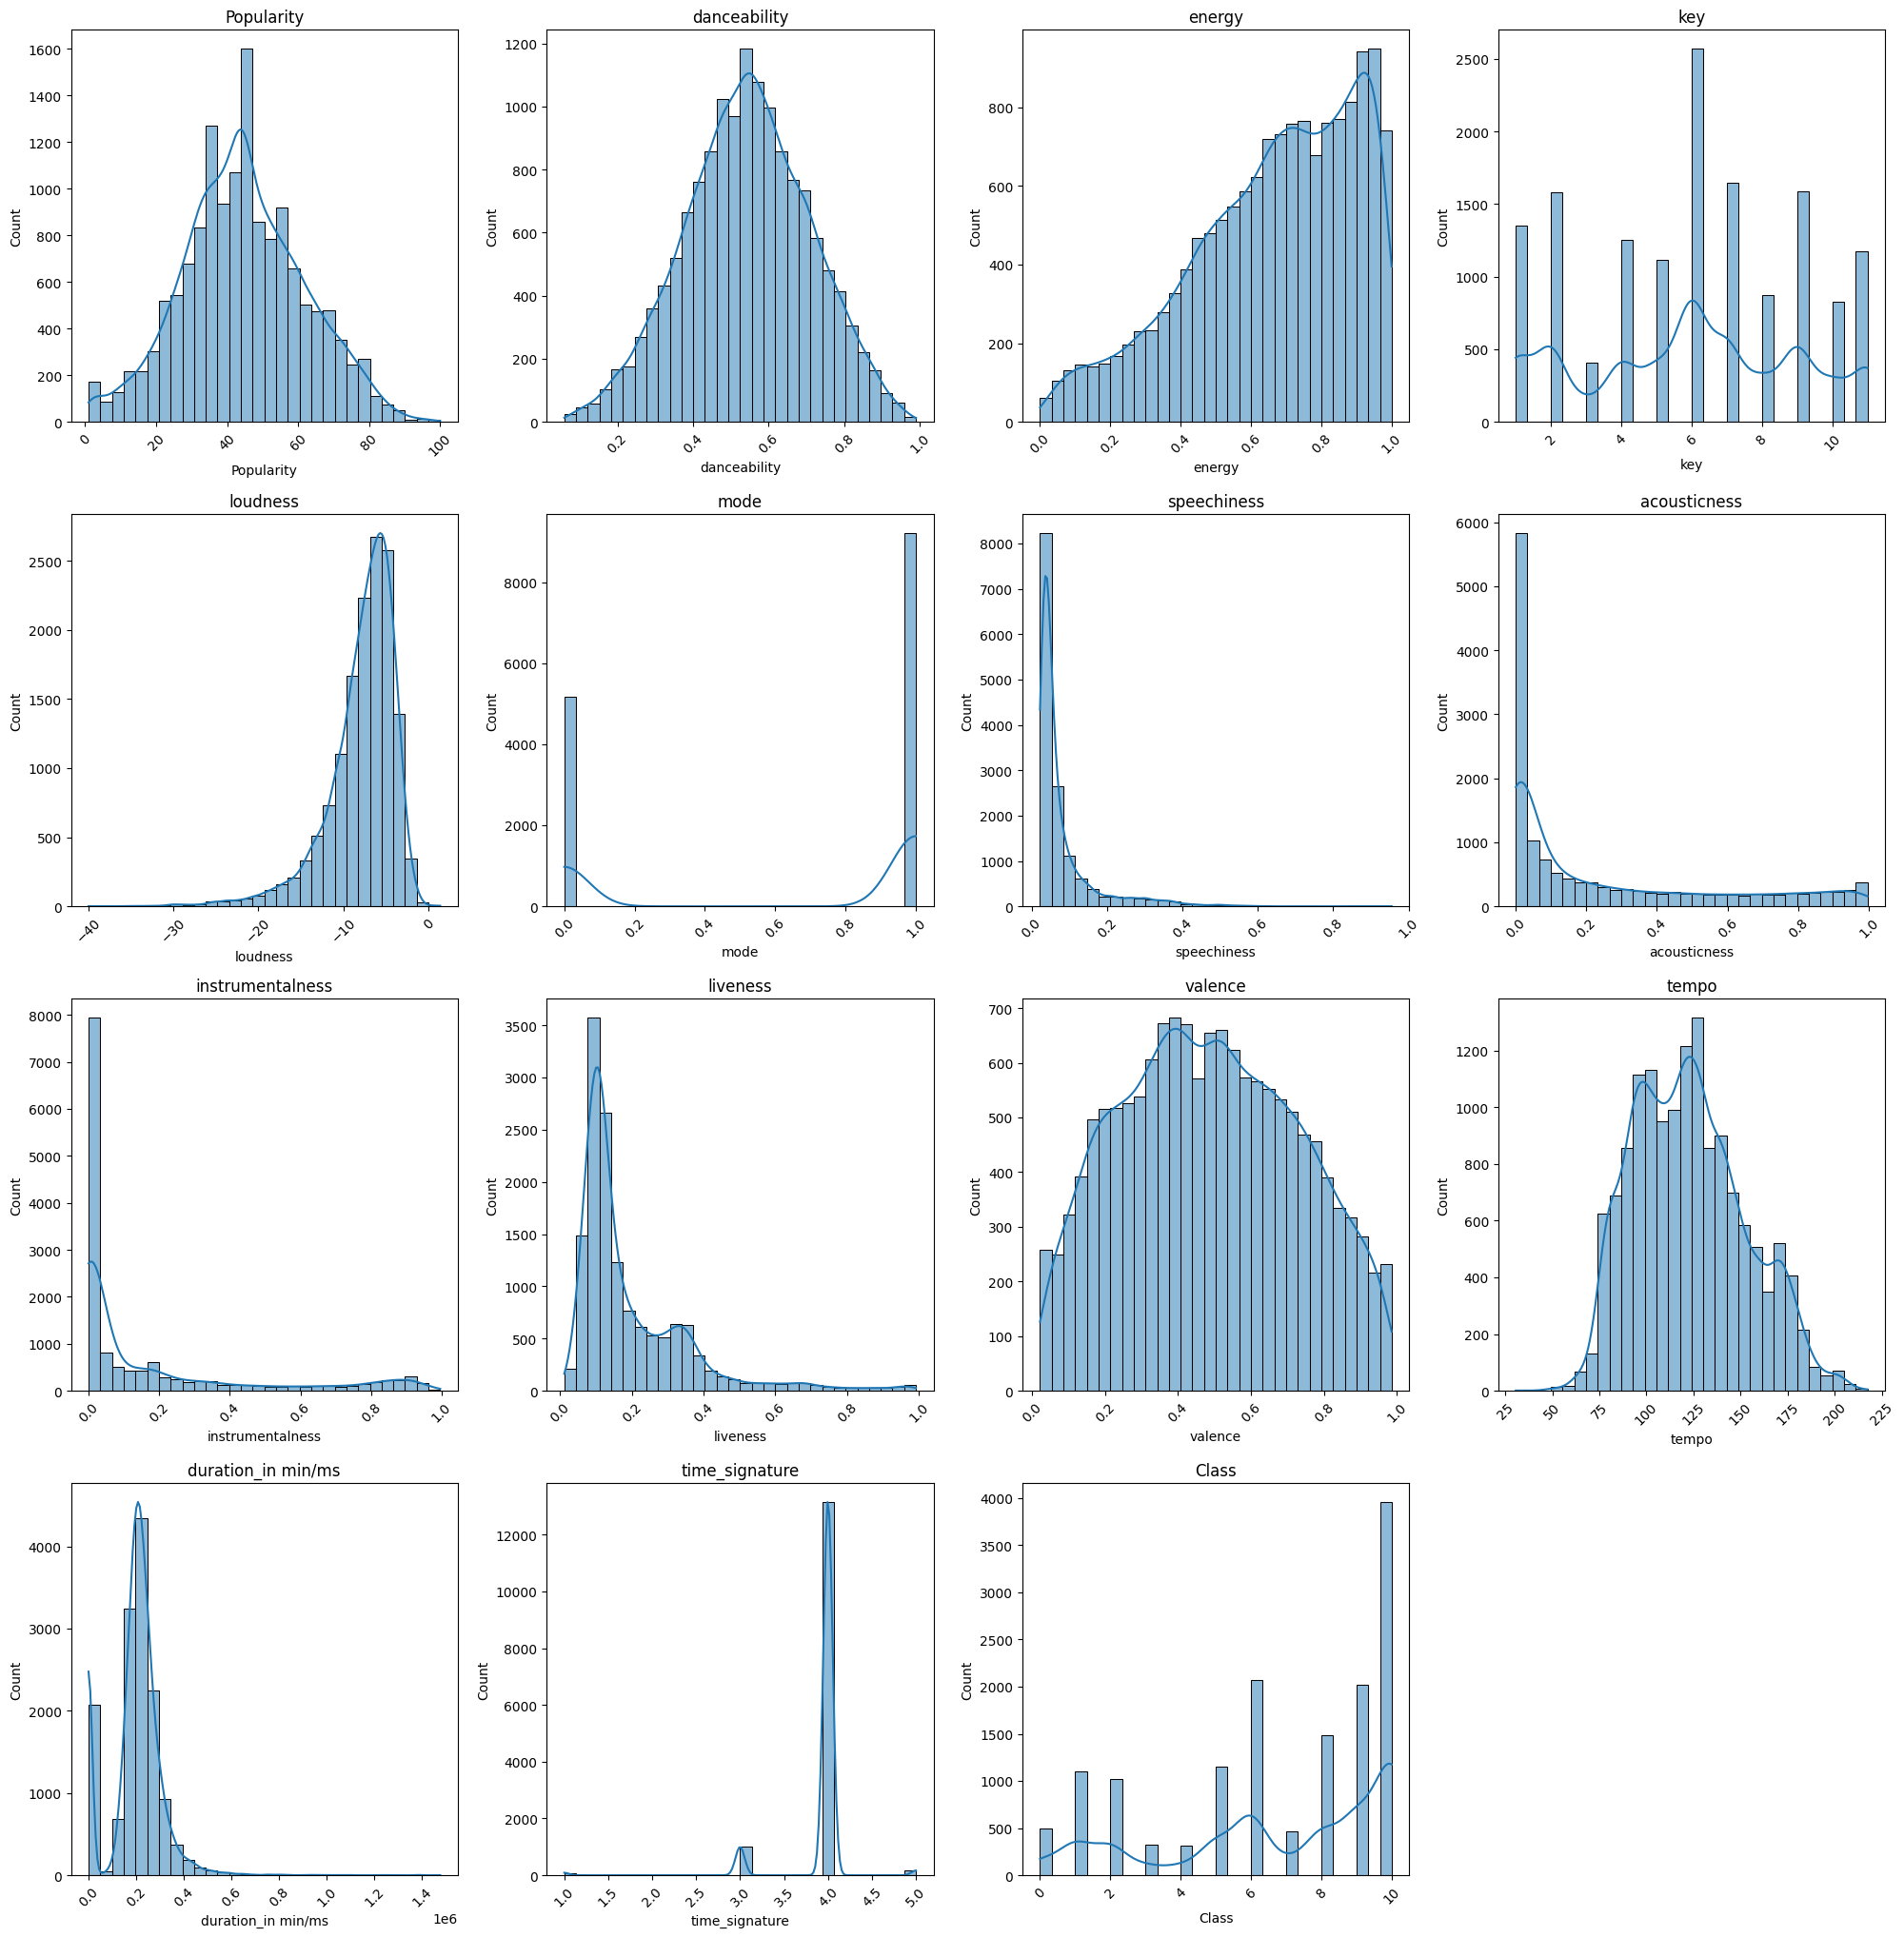

In [29]:
# Tính toán số lượng subplot cần thiết
numeric_cols = df_train.select_dtypes(include=['number']).drop(columns=['Id']).columns.tolist()
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # 3 cột mỗi hàng

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()  # Chuyển thành mảng 1 chiều để dễ duyệt

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(df_train[col], kde=True, bins=30, ax=axes[i])
        # sns.boxplot(x=col, y='SalePrice', data=df_output, ax=axes[i])
        axes[i].set_title(f'{col}')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        break

# Ẩn các subplot thừa
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

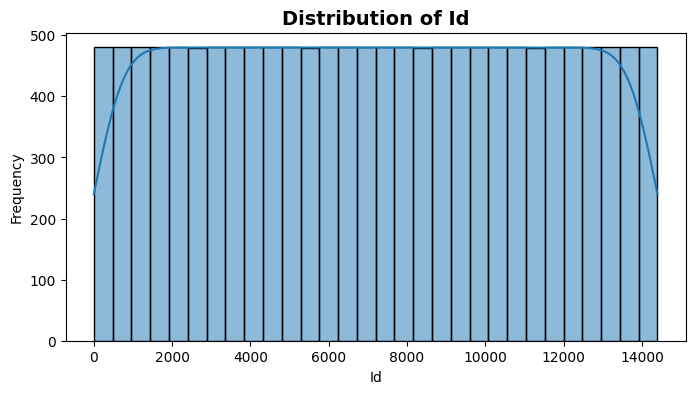

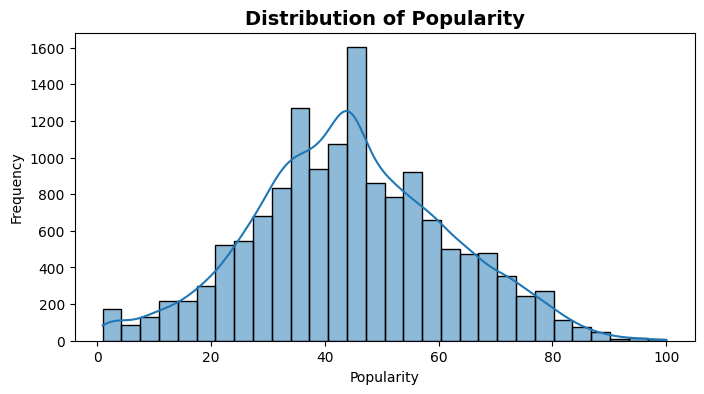

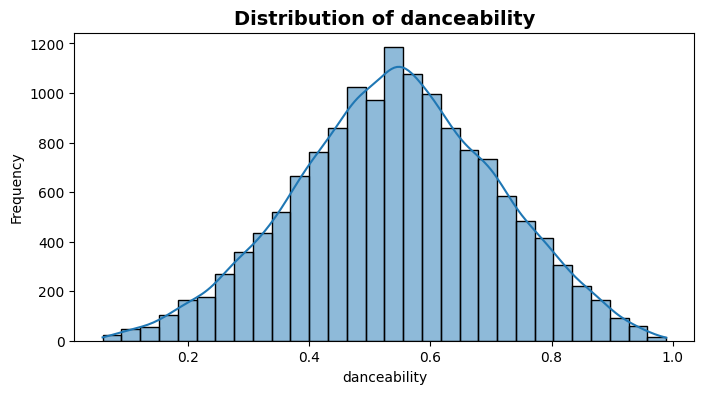

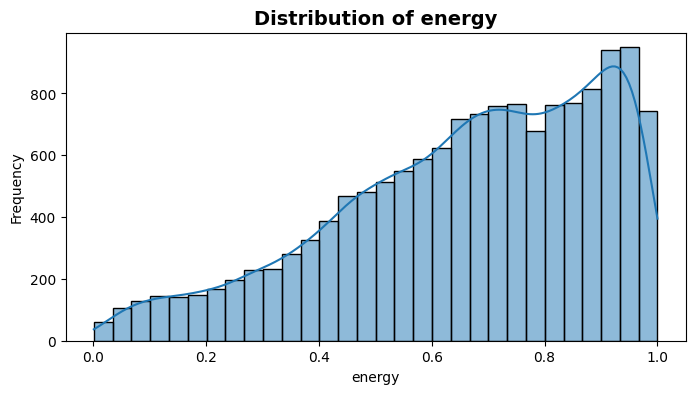

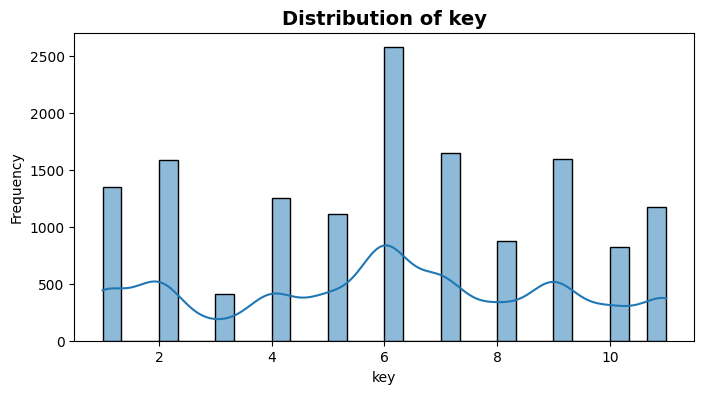

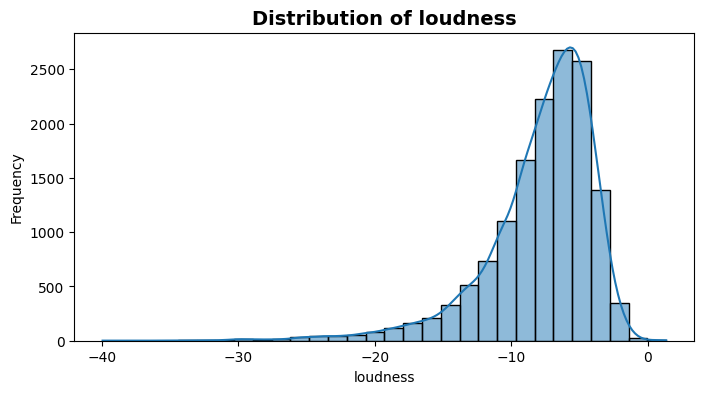

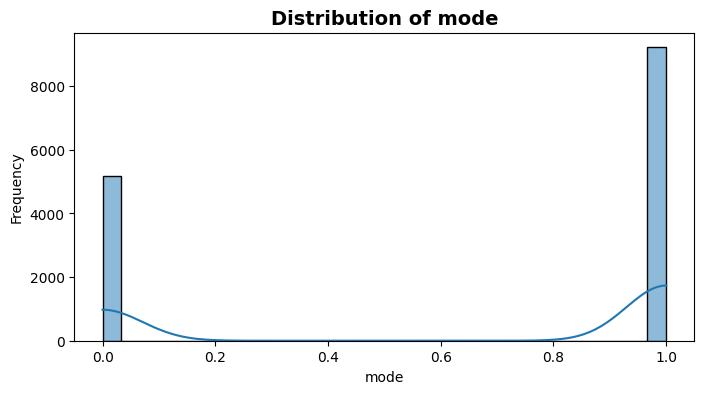

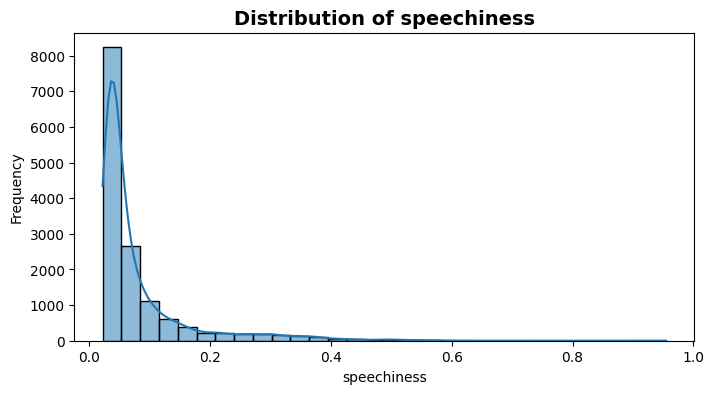

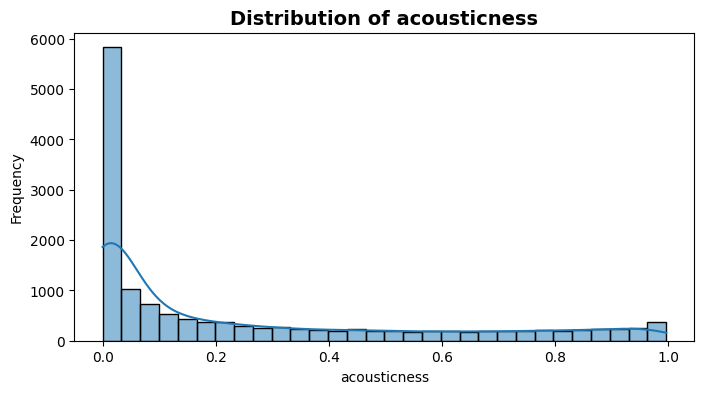

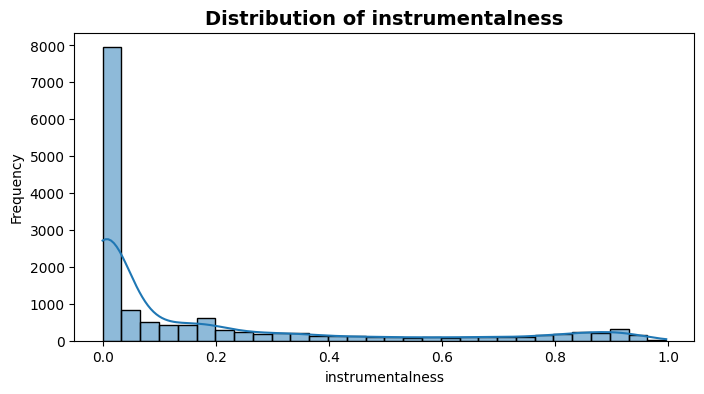

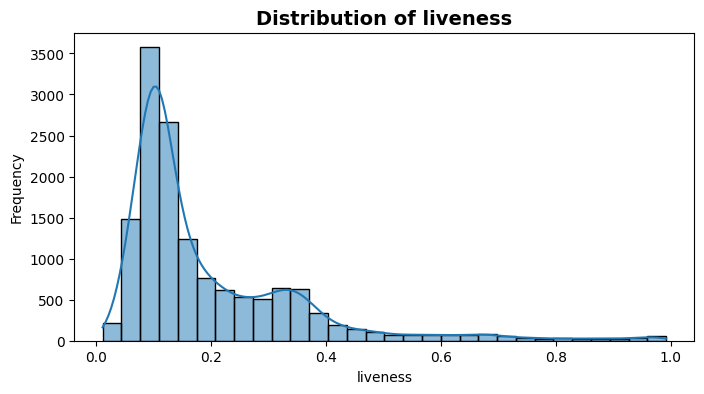

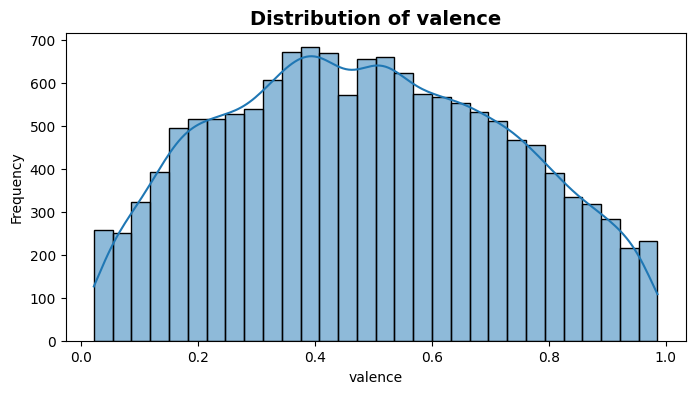

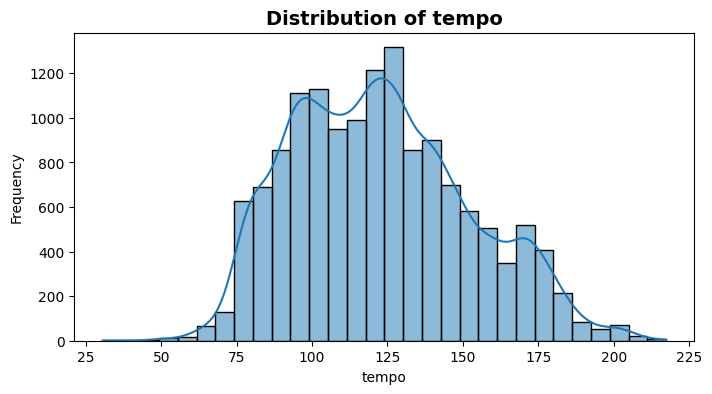

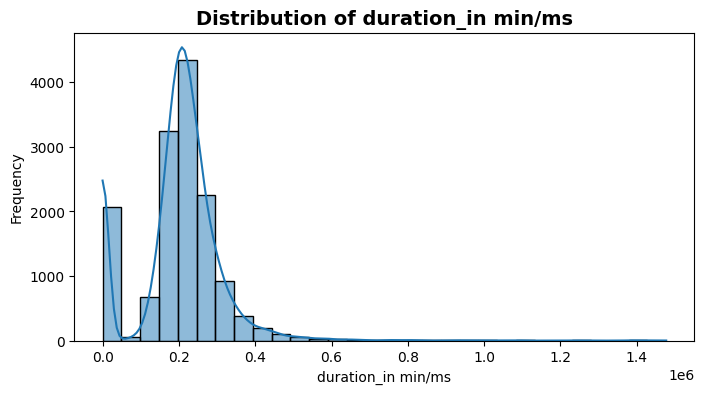

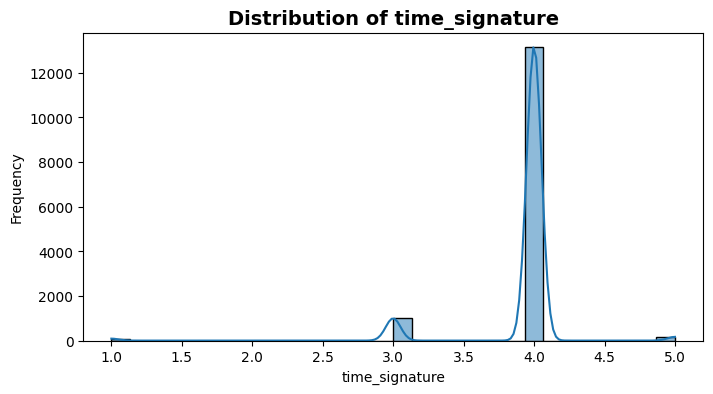

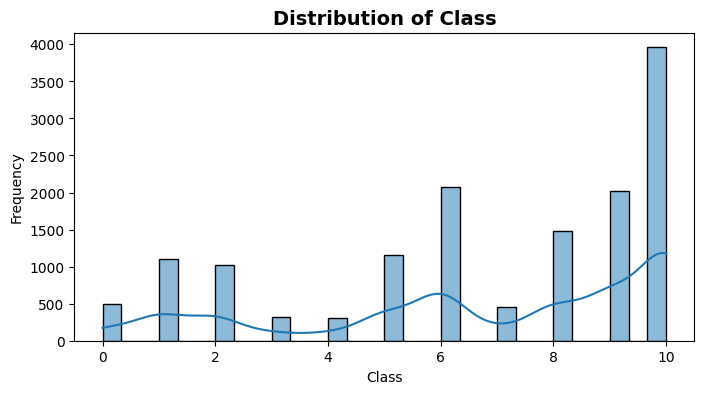

In [25]:
numeric_cols = df_train.select_dtypes(include=['number']).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Nhật xét:

- 'Popularity': "🎵 Độ phổ biến: Giá trị càng cao càng được yêu thích"
- => Thuộc tính phân phối khá tương đối, các giá trị tập trung ở khoảng trung vị, không có outlier
- 'danceability': "💃 Khả năng nhảy múa: 0-1, giá trị cao = dễ nhảy theo",
- => Thuộc tính phân phối khá tương đối, các giá trị tập trung ở khoảng trung vị, không có outlier
- 'energy': "⚡ Năng lượng: 0-1, giá trị cao = sôi động, mạnh mẽ",
- => Thuộc tính phân phối từ thấp đến cao, năng lượng càng cao thì số lượng càng lớn, không có outlier
- 'key': "🎹 Khóa nhạc: 0-11 tương ứng các nốt nhạc (C, C#, D, ...)",
- => Thuộc tính phân phối khá đều, không có outlier
- 'loudness': "🔊 Độ to: Đơn vị dB, giá trị âm (càng gần 0 càng to)",
- => Thuộc tính phân phối khá lệch phải, có giá trị outlier
- 'mode': "🎼 Chế độ: 0=minor (buồn), 1=major (vui)",
- => Tỷ lệ vui nhiều hơn buồn nhưng không quá đáng kể, không có outlier
- 'speechiness': "🎤 Độ nói: 0-1, >0.66=chủ yếu nói, 0.33-0.66=rap, <0.33=nhạc",
- => Thuộc tính phân phối lệch phải, đa phần tập trung ở giá trị thấp nhưng giá trị càng tăng thì số lượng càng ít, có outlier.
- 'acousticness': "🎸 Độ acoustic: 0-1, giá trị cao = nhạc acoustic",
- => Thuộc tính phân phối lệch phải, đa phần tập trung ở giá trị thấp nhưng giá trị càng tăng thì số lượng càng ít, có outlier.
- 'instrumentalness': "🎺 Độ nhạc cụ: 0-1, >0.5=không có vocal",
- => Thuộc tính phân phối lệch phải, đa phần tập trung ở giá trị thấp nhưng giá trị càng tăng thì số lượng càng ít, có outlier.
- 'liveness': "🎤 Độ live: 0-1, giá trị cao = thu âm trực tiếp",
- => Thuộc tính phân phối lệch phải, đa phần tập trung ở giá trị thấp nhưng giá trị càng tăng thì số lượng càng ít, có outlier.
- 'valence': "😊 Độ tích cực: 0-1, giá trị cao = vui vẻ, tích cực",
- => Thuộc tính phân phối khá tương đối, các giá trị tập trung ở khoảng trung vị, không có outlier
- 'tempo': "🎵 Nhịp độ: BPM (beats per minute), càng cao càng nhanh",
- => Thuộc tính phân phối khá tương đối, các giá trị tập trung ở khoảng trung vị, không có outlier
- 'duration_ms': "⏱️ Thời lượng: Milliseconds, 1000ms = 1 giây",
- 'time_signature': "🎵 Ký hiệu nhịp: Số beat trong 1 measure"
- => Tập trung ở giá trị 3 4, có outlier


In [26]:
object_cols = df_train.select_dtypes(include=['object']).columns.tolist()
object_cols

['Artist Name', 'Track Name']

In [27]:
for col in object_cols:
    print(f"Value counts for column: {col}")
    print(len(df_train[col].unique()))

Value counts for column: Artist Name
7913
Value counts for column: Track Name
12455


Nhận xét:

- Do số lượng giá trị quá lớn nên sẽ drop các cột này


# Phân tích nhị biến


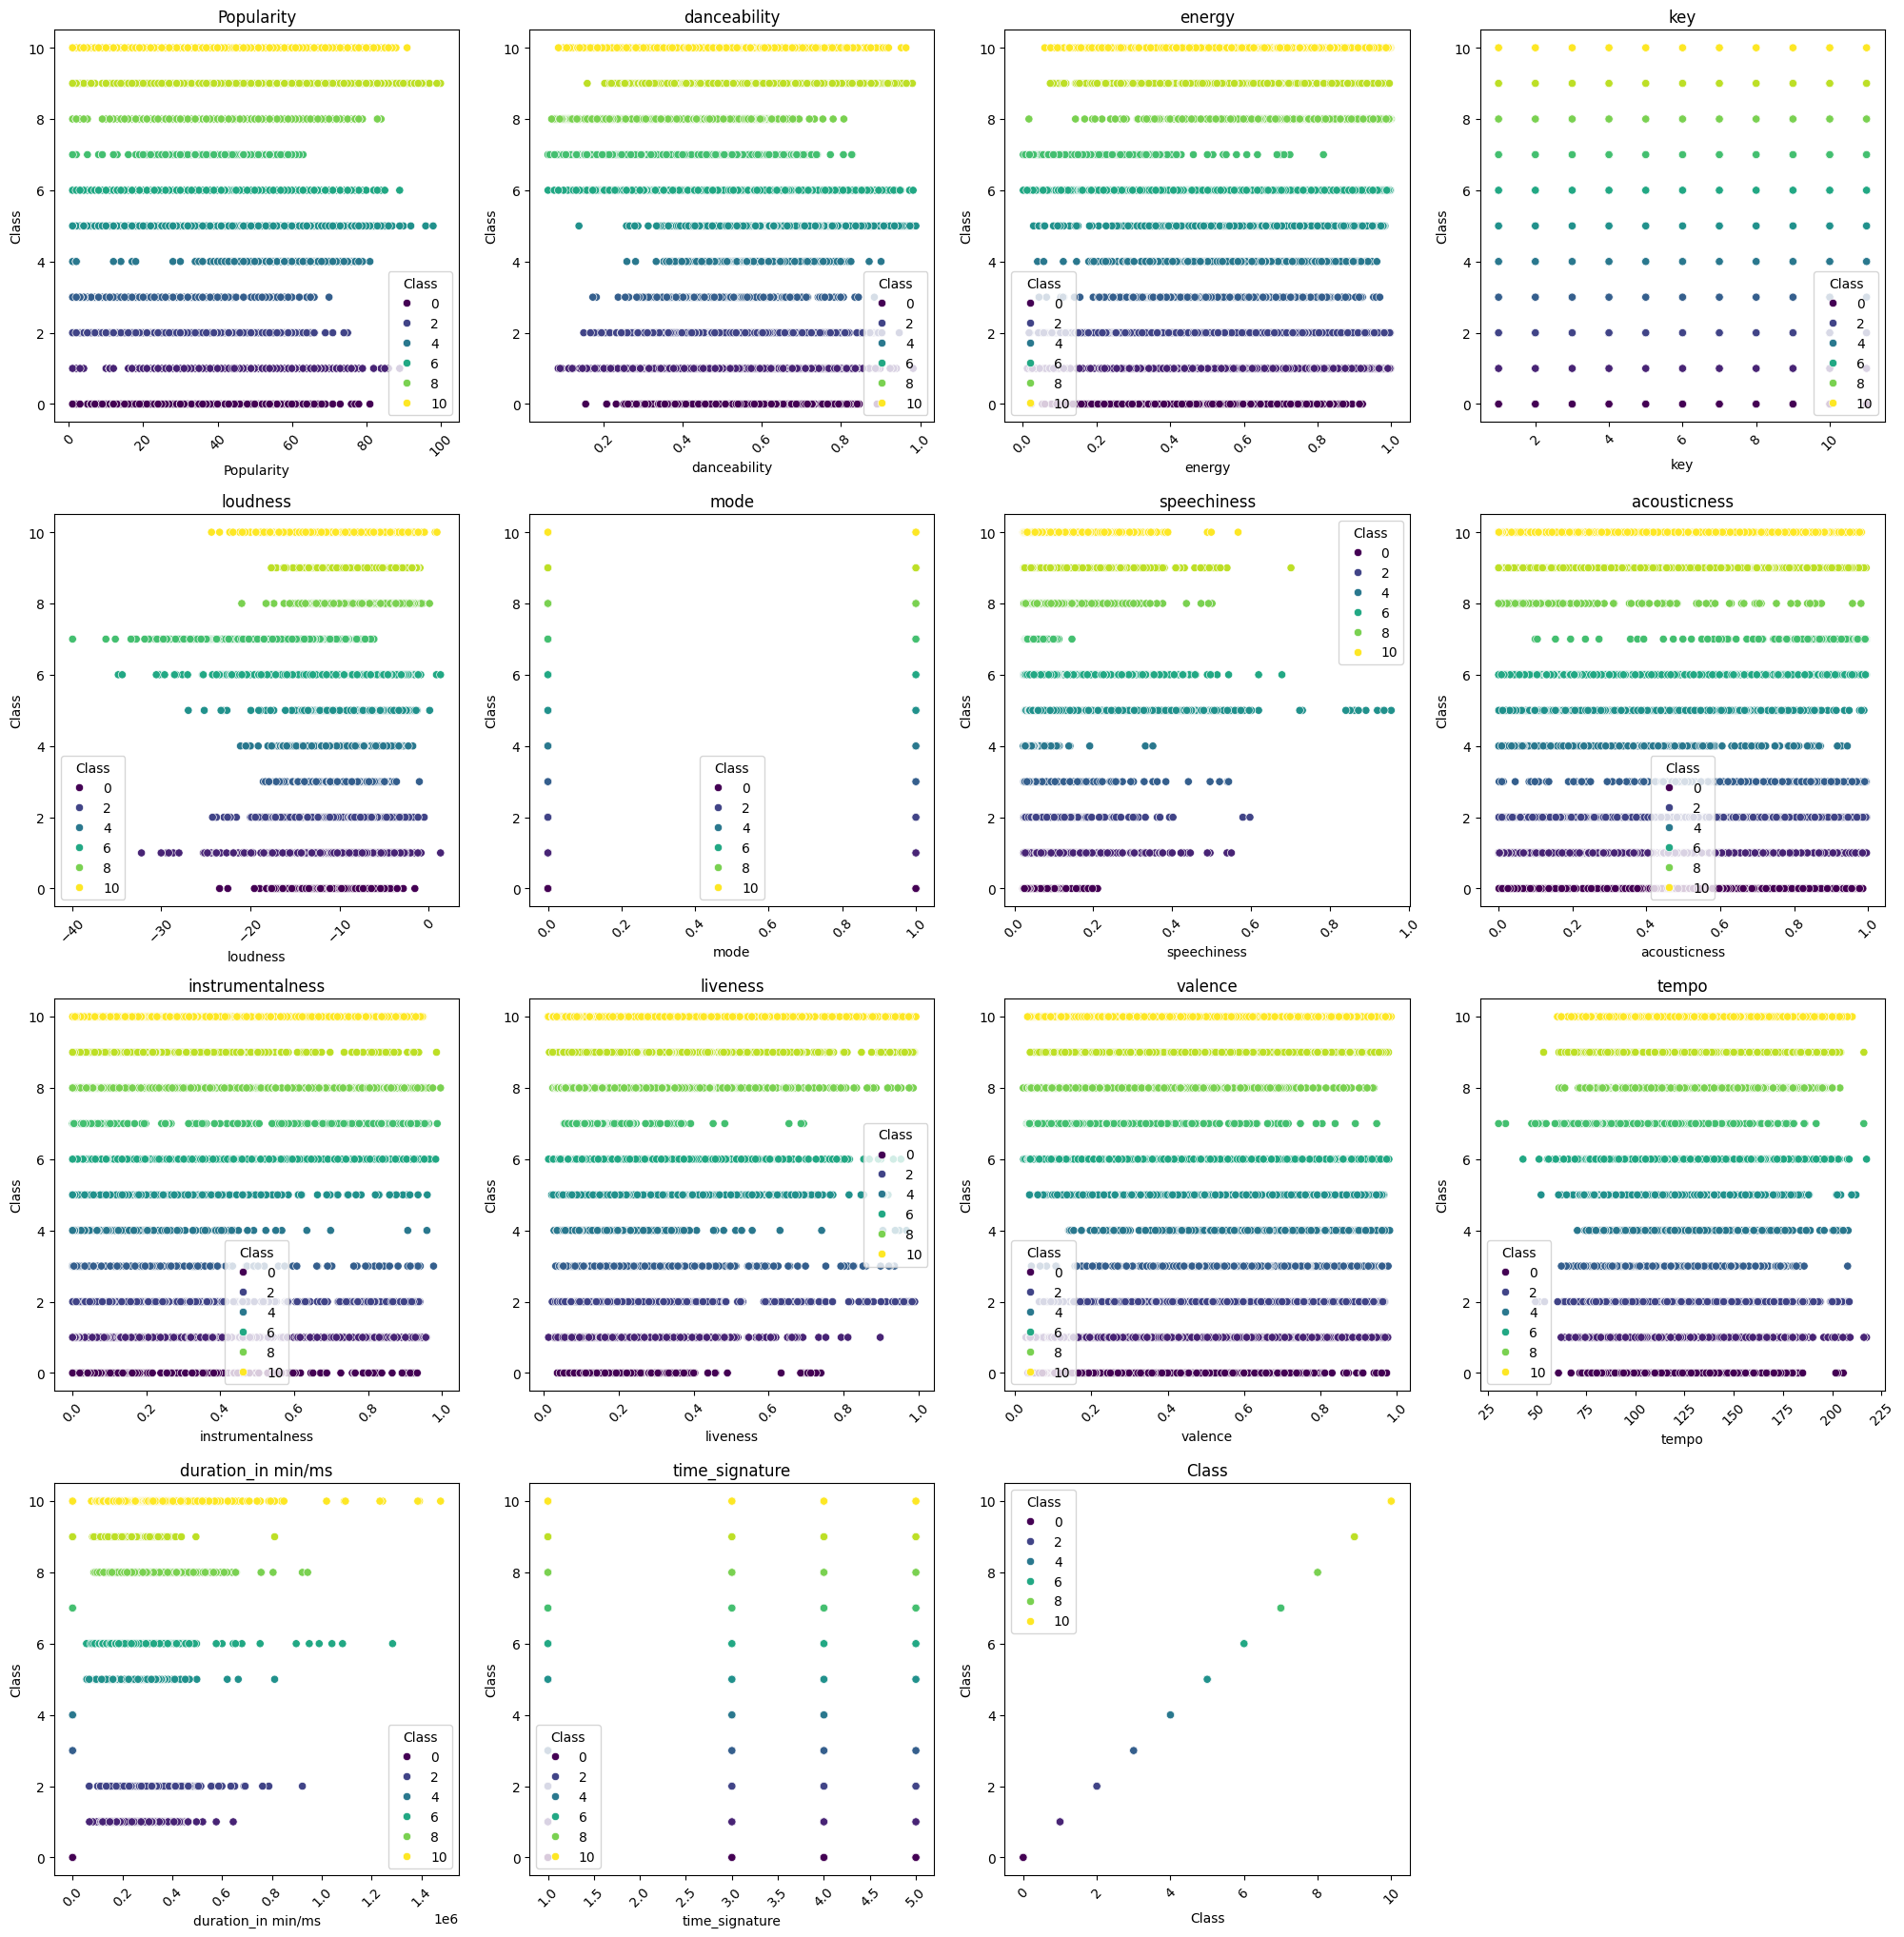

In [39]:
# Tính toán số lượng subplot cần thiết
numeric_cols = df_train.select_dtypes(include=['number']).drop(columns=['Id']).columns.tolist()
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # 3 cột mỗi hàng

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()  # Chuyển thành mảng 1 chiều để dễ duyệt

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.scatterplot(x=col, y='Class', data=df_train, ax=axes[i], hue='Class', palette='viridis')
        axes[i].set_title(f'{col}')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        break

# Ẩn các subplot thừa
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

<Axes: >

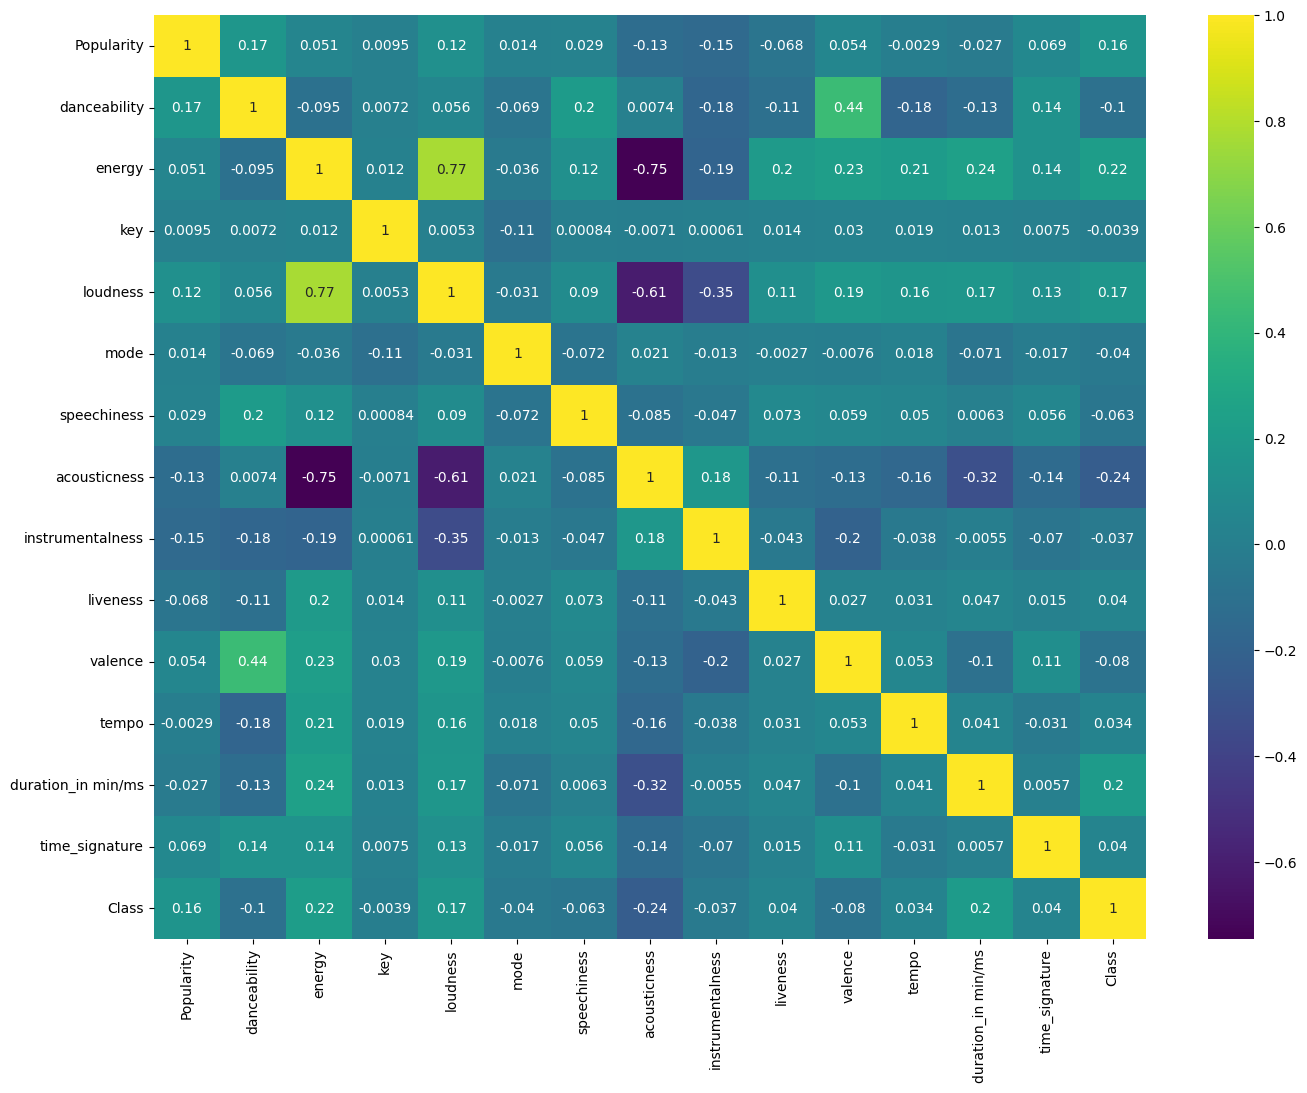

In [36]:
plt.figure(figsize=(16,12))
sns.heatmap(df_train.select_dtypes(include=['number']).drop(columns=['Id']).corr(), cmap='viridis', annot=True)

In [37]:
df_train.select_dtypes(include=['number']).drop(columns=['Id']).corr()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
Popularity,1.000000,0.171299,0.051051,0.009462,0.122426,0.013600,0.028951,-0.126982,-0.149288,-0.067602,0.054072,-0.002929,-0.027237,0.069452,0.156752
danceability,0.171299,1.000000,-0.094806,0.007196,0.056193,-0.069311,0.202985,0.007414,-0.178992,-0.105949,0.444798,-0.180764,-0.127245,0.137127,-0.101152
energy,0.051051,-0.094806,1.000000,0.011879,0.769586,-0.035974,0.120869,-0.746436,-0.187495,0.197802,0.227542,0.205421,0.241190,0.142971,0.215611
key,0.009462,0.007196,0.011879,1.000000,0.005269,-0.107390,0.000839,-0.007124,0.000614,0.013802,0.029770,0.018803,0.013400,0.007451,-0.003929
loudness,0.122426,0.056193,0.769586,0.005269,1.000000,-0.030553,0.090473,-0.614967,-0.350499,0.113663,0.185779,0.161750,0.169003,0.125978,0.174111
mode,0.013600,-0.069311,-0.035974,-0.107390,-0.030553,1.000000,-0.072489,0.020817,-0.013421,-0.002697,-0.007580,0.017616,-0.070849,-0.016817,-0.040092
speechiness,0.028951,0.202985,0.120869,0.000839,0.090473,-0.072489,1.000000,-0.084849,-0.047359,0.072569,0.059227,0.049739,0.006253,0.055992,-0.062784
acousticness,-0.126982,0.007414,-0.746436,-0.007124,-0.614967,0.020817,-0.084849,1.000000,0.175263,-0.109400,-0.127707,-0.162988,-0.321357,-0.139500,-0.240609
instrumentalness,-0.149288,-0.178992,-0.187495,0.000614,-0.350499,-0.013421,-0.047359,0.175263,1.000000,-0.043386,-0.204873,-0.037856,-0.005473,-0.069551,-0.036741
liveness,-0.067602,-0.105949,0.197802,0.013802,0.113663,-0.002697,0.072569,-0.109400,-0.043386,1.000000,0.027385,0.030776,0.046579,0.014825,0.040101
